# TP5 - Imputation Avancée (KNN, MICE)

**Difficulté:** Intermédiaire  
**Dataset:** housing_missing.csv  
**Description:** Techniques d'imputation sophistiquées pour valeurs manquantes

---


## Imports des Bibliothèques


In [2]:
# Bibliothèques de base
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# Configuration des graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Ignorer les warnings
import warnings
warnings.filterwarnings('ignore')

# Affichage pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

print(" Bibliothèques importées avec succès!")

 Bibliothèques importées avec succès!


## Import du Dataset


In [3]:
# Charger le dataset
df = pd.read_csv('data/housing_missing.csv')

# Afficher les informations de base
print(f"📏 Dimensions: {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f" Taille mémoire: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("\n" + "="*80 + "\n")

# Aperçu des données
display(df.head())
print("\n" + "="*80 + "\n")

# Informations sur les colonnes
df.info()

📏 Dimensions: 600 lignes × 8 colonnes
 Taille mémoire: 0.04 MB




,price,size,bedrooms,bathrooms,garage,location_score,age,condition
0,383622.11,120.01,5.00,1,1.00,1.12,7,Fair
1,226098.11,186.06,NaN,2,NaN,9.29,6,Poor
2,314155.08,128.99,5.00,2,0.00,2.16,33,Good
3,57695.35,79.31,3.00,2,0.00,5.01,43,Poor
4,342892.04,158.58,1.00,1,0.00,8.34,13,Fair




<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   price           550 non-null    float64
 1   size            600 non-null    float64
 2   bedrooms        560 non-null    float64
 3   bathrooms       600 non-null    int64  
 4   garage          557 non-null    float64
 5   location_score  600 non-null    float64
 6   age             600 non-null    int64  
 7   condition       600 non-null    str    
dtypes: float64(5), int64(2), str(1)
memory usage: 40.0 KB


## Visualisation des Valeurs Manquantes


<Figure size 1400x800 with 0 Axes>

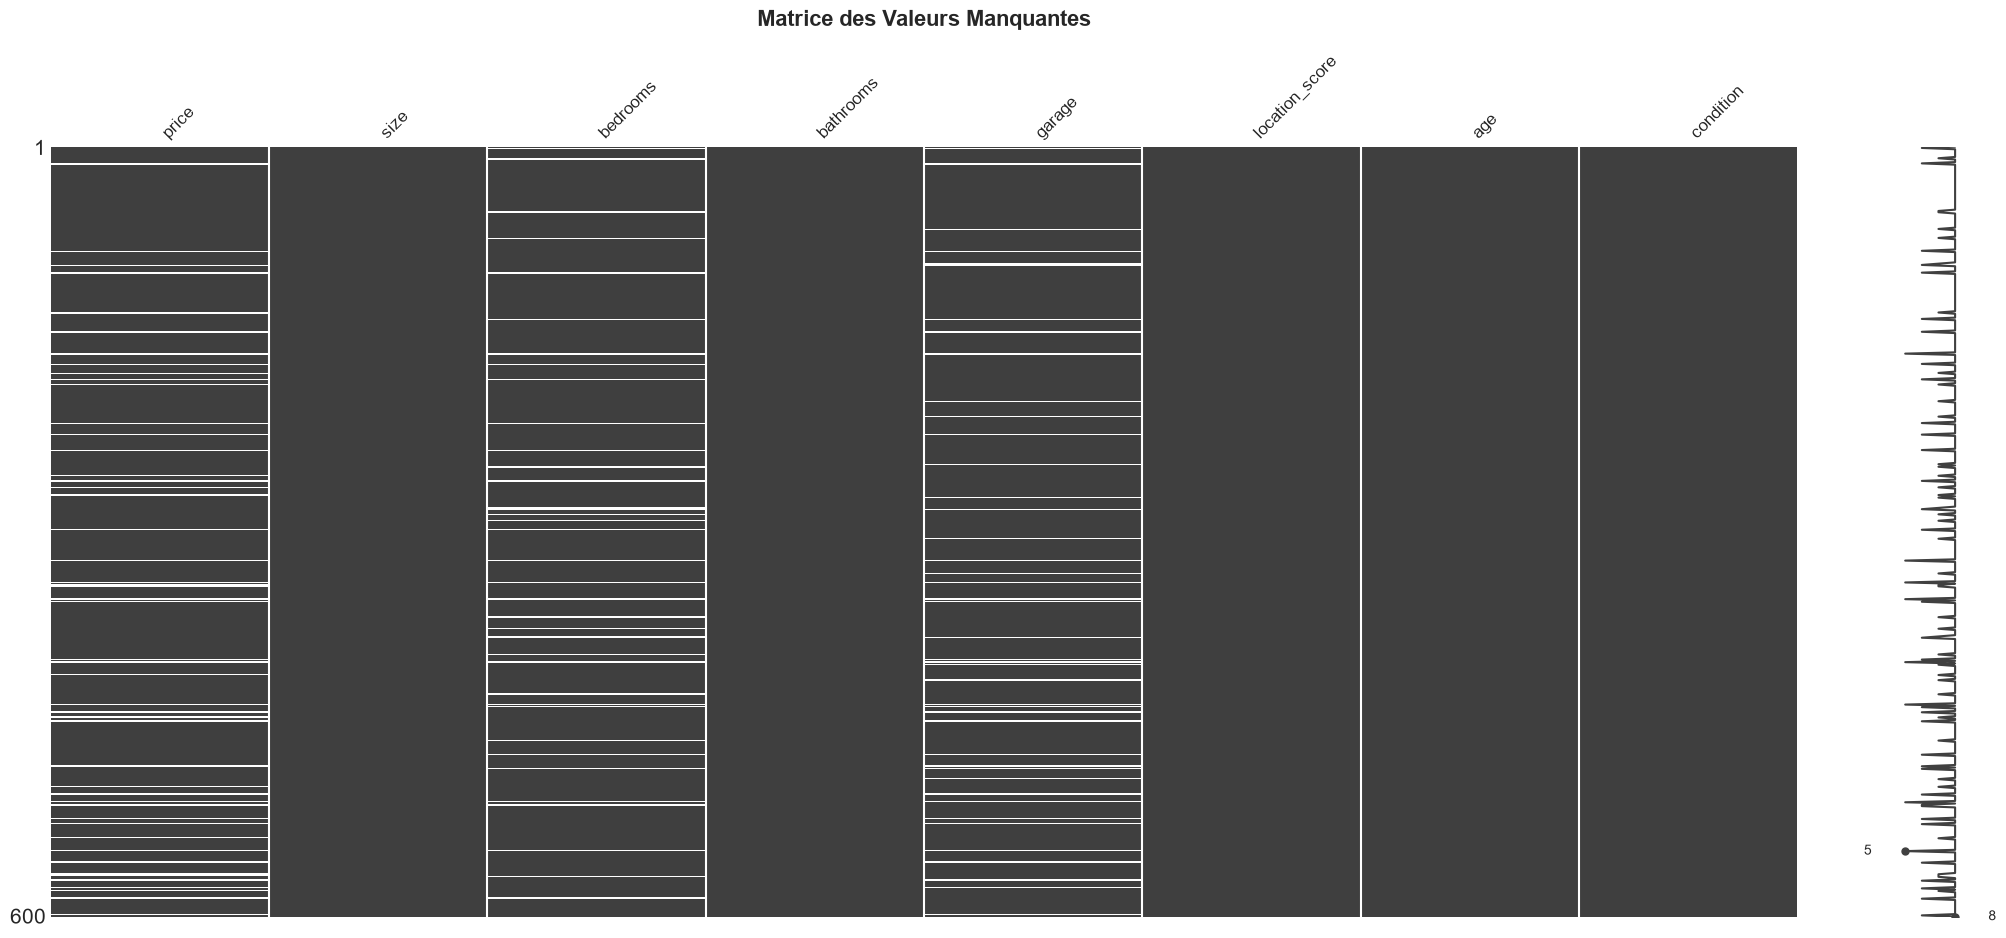


📊 Statistiques des Valeurs Manquantes:



,Nombre_Missing,Pourcentage_Missing
price,50,8.33
garage,43,7.17
bedrooms,40,6.67


In [4]:
# Matrice de visualisation des valeurs manquantes
plt.figure(figsize=(14, 8))
msno.matrix(df, fontsize=12, sparkline=True)
plt.title("Matrice des Valeurs Manquantes", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Statistiques des valeurs manquantes
missing_stats = pd.DataFrame({
    'Nombre_Missing': df.isnull().sum(),
    'Pourcentage_Missing': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Pourcentage_Missing', ascending=False)

print("\n📊 Statistiques des Valeurs Manquantes:\n")
display(missing_stats[missing_stats['Nombre_Missing'] > 0])


## Questions Préalables

**Avant de commencer le TP, répondez aux questions suivantes en analysant le dataset:**

1. Quel est le pattern de valeurs manquantes (MCAR, MAR, MNAR) ?
2. Y a-t-il une corrélation entre les variables avec missing values ?
3. Quelle méthode d'imputation serait la plus appropriée ?
4. Comment la moyenne change-t-elle avec différentes imputations ?
5. L'imputation par KNN préserve-t-elle mieux les corrélations ?
6. Combien de voisins (k) semble optimal pour KNN ?
7. MICE converge-t-il rapidement (nombre d'itérations) ?
8. Y a-t-il des différences significatives entre les méthodes ?
9. Faut-il créer des indicateurs de missingness ?
10. Quelle méthode préserve le mieux la distribution originale ?


In [5]:
#  Cellule pour vos réponses et analyses
# Utilisez cette cellule pour explorer les données et répondre aux questions
# Exemple d'analyses:
# df.describe()
# df['colonne'].value_counts()
# df.isnull().sum()
# etc.


print("Réponses aux questions:")
print("="*80)
print("Question 1 :")
print(" * les prix ne sont pas déclarés pour les surfaces les plus importantes, sans doute les prix les plus élevés")
print(" * idem pour le nombre de chambres")
print(" * idem pour le nombre de garages")
print("Le pattern est donc plutôt MAR")
print("Question 2 :")
print(" * dans en gros 1/3 des cas, une valeur manquante est associée à une autre, alors que ces lignes correspondent à 1/15 du global")
print("  => il est donc 5 fois plus probable d'avoir une seconde valeur manquante lorsqu'il y en a déjà une")
print("Question 3 :")
print(" * il n'existe pas de régression linéaire entre surface et prix ou nombre de chambres ou nombre de garages")
print(" * remplacer les valeurs manquantes par une moyenne ou même une médiane n'a pas de sens dans ce contexte très diversifié")
print(" * la moins mauvaise solution semble être celle qui se base sur des données voisines, autrement dit la méthode KNN")
print("Question 4 :")

# Écrivez vos réponses ici


Réponses aux questions:


{'whiskers': [<matplotlib.lines.Line2D at 0x1acd51b8440>,
 'caps': [<matplotlib.lines.Line2D at 0x1acd51b86e0>,
 'boxes': [<matplotlib.lines.Line2D at 0x1acd51b82f0>],
 'medians': [<matplotlib.lines.Line2D at 0x1acd51b8980>],
 'fliers': [<matplotlib.lines.Line2D at 0x1acd51b8ad0>],
 'means': []}

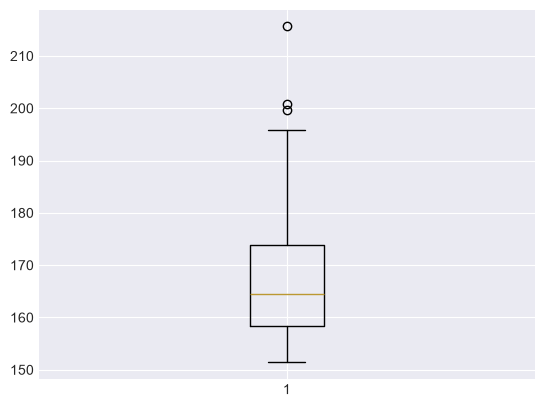

In [6]:
plt.boxplot(df[df.price.isna()]["size"])

{'whiskers': [<matplotlib.lines.Line2D at 0x1acda3638c0>,
 'caps': [<matplotlib.lines.Line2D at 0x1acda363b60>,
 'boxes': [<matplotlib.lines.Line2D at 0x1acda363770>],
 'medians': [<matplotlib.lines.Line2D at 0x1acda363e00>],
 'fliers': [<matplotlib.lines.Line2D at 0x1acda3c8050>],
 'means': []}

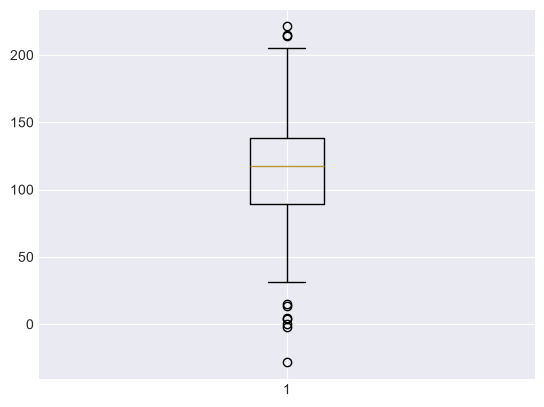

In [9]:
plt.boxplot(df[df.price.notnull()]["size"])

{'whiskers': [<matplotlib.lines.Line2D at 0x1acda3caa50>,
 'caps': [<matplotlib.lines.Line2D at 0x1acda3cacf0>,
 'boxes': [<matplotlib.lines.Line2D at 0x1acda3ca900>],
 'medians': [<matplotlib.lines.Line2D at 0x1acda3caf90>],
 'fliers': [<matplotlib.lines.Line2D at 0x1acda3cb0e0>],
 'means': []}

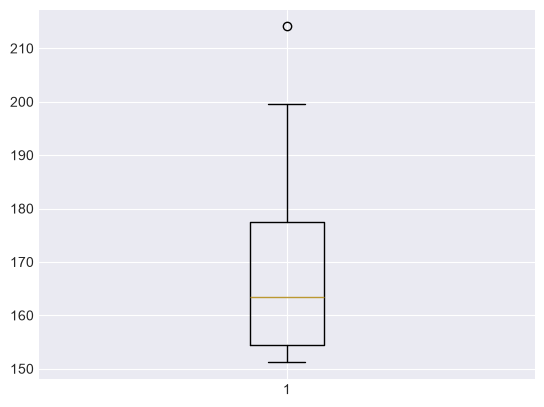

In [10]:
plt.boxplot(df[df.bedrooms.isna()]["size"])

{'whiskers': [<matplotlib.lines.Line2D at 0x1acda42a3c0>,
 'caps': [<matplotlib.lines.Line2D at 0x1acda42a660>,
 'boxes': [<matplotlib.lines.Line2D at 0x1acda42a270>],
 'medians': [<matplotlib.lines.Line2D at 0x1acda42a900>],
 'fliers': [<matplotlib.lines.Line2D at 0x1acda42aa50>],
 'means': []}

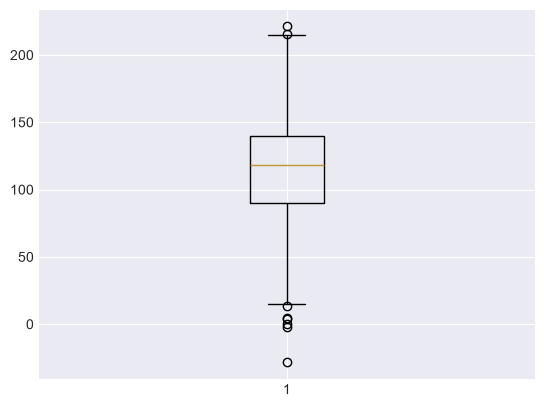

In [11]:
plt.boxplot(df[df.bedrooms.notnull()]["size"])

{'whiskers': [<matplotlib.lines.Line2D at 0x1acda49d550>,
 'caps': [<matplotlib.lines.Line2D at 0x1acda49d7f0>,
 'boxes': [<matplotlib.lines.Line2D at 0x1acda49d400>],
 'medians': [<matplotlib.lines.Line2D at 0x1acda49da90>],
 'fliers': [<matplotlib.lines.Line2D at 0x1acda49dbe0>],
 'means': []}

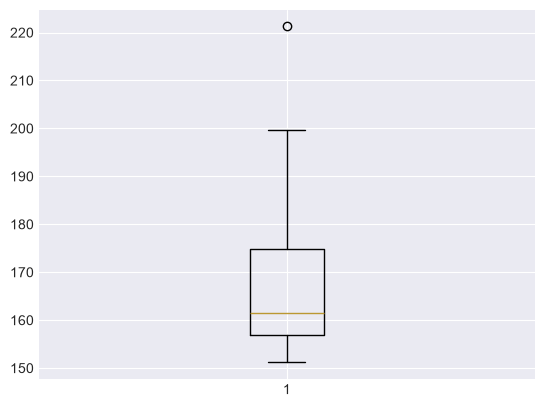

In [12]:
plt.boxplot(df[df.garage.isna()]["size"])

{'whiskers': [<matplotlib.lines.Line2D at 0x1acda4f12b0>,
 'caps': [<matplotlib.lines.Line2D at 0x1acda4f1550>,
 'boxes': [<matplotlib.lines.Line2D at 0x1acda4f1160>],
 'medians': [<matplotlib.lines.Line2D at 0x1acda4f17f0>],
 'fliers': [<matplotlib.lines.Line2D at 0x1acda4f1940>],
 'means': []}

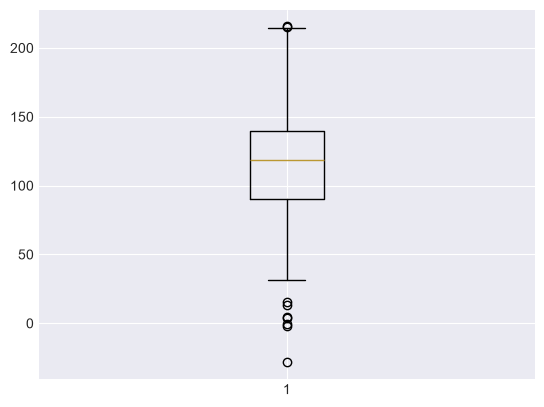

In [13]:
plt.boxplot(df[df.garage.notnull()]["size"])

{'whiskers': [<matplotlib.lines.Line2D at 0x1acda65c2f0>,
 'caps': [<matplotlib.lines.Line2D at 0x1acda65c590>,
 'boxes': [<matplotlib.lines.Line2D at 0x1acda65c1a0>],
 'medians': [<matplotlib.lines.Line2D at 0x1acda65c830>],
 'fliers': [<matplotlib.lines.Line2D at 0x1acda65c980>],
 'means': []}

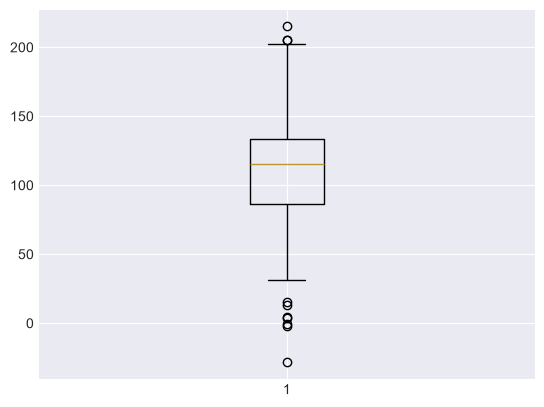

In [15]:
plt.boxplot(df.dropna()["size"])

{'whiskers': [<matplotlib.lines.Line2D at 0x1acda65f380>,
 'caps': [<matplotlib.lines.Line2D at 0x1acda65f620>,
 'boxes': [<matplotlib.lines.Line2D at 0x1acda65f230>],
 'medians': [<matplotlib.lines.Line2D at 0x1acda65f8c0>],
 'fliers': [<matplotlib.lines.Line2D at 0x1acda65fa10>],
 'means': []}

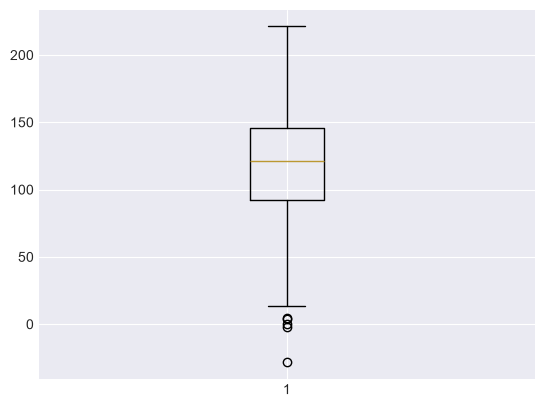

In [16]:
plt.boxplot(df["size"])

{'whiskers': [<matplotlib.lines.Line2D at 0x1acda6be510>,
 'caps': [<matplotlib.lines.Line2D at 0x1acda6be7b0>,
 'boxes': [<matplotlib.lines.Line2D at 0x1acda6be3c0>],
 'medians': [<matplotlib.lines.Line2D at 0x1acda6bea50>],
 'fliers': [<matplotlib.lines.Line2D at 0x1acda6beba0>],
 'means': []}

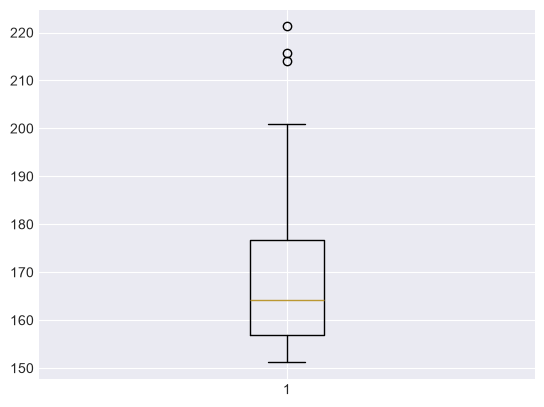

In [21]:
plt.boxplot(df[df["bedrooms"].isna()|df["price"].isna()|df["garage"].isna()]["size"])

{'whiskers': [<matplotlib.lines.Line2D at 0x1acda6fa270>,
 'caps': [<matplotlib.lines.Line2D at 0x1acda6fa510>,
 'boxes': [<matplotlib.lines.Line2D at 0x1acda6fa120>],
 'medians': [<matplotlib.lines.Line2D at 0x1acda6fa7b0>],
 'fliers': [<matplotlib.lines.Line2D at 0x1acda6fa900>],
 'means': []}

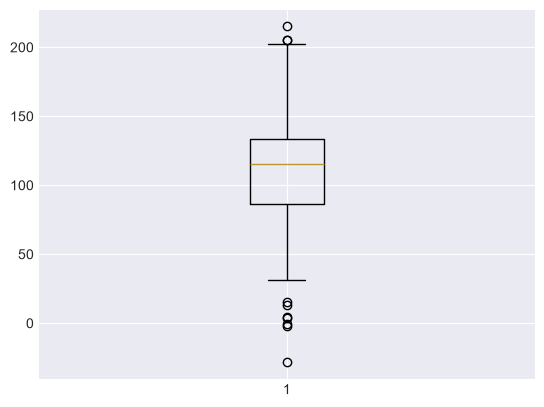

In [22]:
plt.boxplot(df[df["bedrooms"].notnull()&df["price"].notnull()&df["garage"].notnull()]["size"])

In [24]:
print(df["bedrooms"].isna().sum(),df[df["price"].isna()]["bedrooms"].isna().sum())

40 18


In [25]:
print(df["garage"].isna().sum(),df[df["price"].isna()]["garage"].isna().sum())

43 25


In [26]:
print(df["garage"].isna().sum(),df[df["bedrooms"].isna()]["garage"].isna().sum())

43 15


In [27]:
print(df["price"].isna().sum(),df[df["bedrooms"].isna()]["price"].isna().sum())

50 18


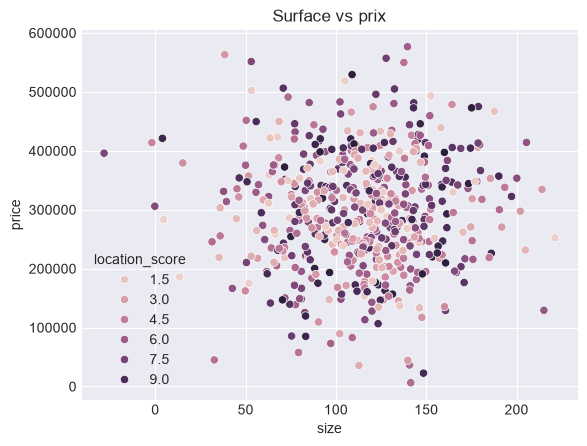

In [48]:
c = sns.scatterplot(data=df[["size","price","location_score"]],x="size",y="price",hue="location_score")
c.set(title='Surface vs prix')
plt.show()

In [38]:
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=5)
df_imputed = pd.DataFrame(
    imputer.fit_transform(df[['price', 'size', 'bedrooms', 'bathrooms', 'garage', 'location_score','age']]),
    columns=['price', 'size', 'bedrooms', 'bathrooms', 'garage', 'location_score','age']
)

In [46]:
df_imputed[df_imputed["bedrooms"]!=df["bedrooms"]]["bedrooms"].round(0)

1     2.00
9     3.00
50    3.00
51    3.00
71    2.00
98    3.00
134   3.00
161   2.00
169   3.00
181   3.00
215   3.00
236   3.00
249   3.00
260   3.00
281   4.00
282   3.00
286   4.00
291   3.00
298   3.00
322   3.00
339   3.00
352   4.00
366   2.00
375   2.00
381   4.00
382   3.00
395   3.00
401   3.00
426   3.00
434   1.00
436   3.00
462   3.00
473   3.00
484   2.00
510   2.00
512   4.00
513   2.00
548   2.00
568   3.00
585   2.00
Name: bedrooms, dtype: float64

## Étapes du TP

**Suivez les étapes ci-dessous pour nettoyer le dataset:**

### Étape 1: Analyser le pattern de missing values (msno.matrix, heatmap)
### Étape 2: Créer des indicateurs de missingness avant imputation
### Étape 3: Séparer en train/test pour évaluer les imputations
### Étape 4: Implémenter l'imputation par moyenne/médiane (baseline)
### Étape 5: Implémenter KNN Imputation avec k=5
### Étape 6: Implémenter MICE (Iterative Imputer)
### Étape 7: Comparer les distributions avant/après pour chaque méthode
### Étape 8: Calculer les métriques de qualité d'imputation
### Étape 9: Visualiser les corrélations préservées
### Étape 10: Sélectionner la meilleure méthode et justifier


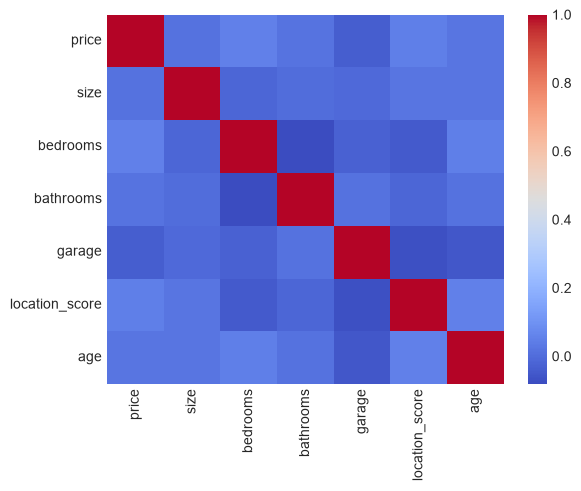

 Étape 1 complétée


In [47]:
# ========================================
# Étape 1: Analyser le pattern de missing values (msno.matrix, heatmap)
# ========================================

# TODO: Écrivez votre code ici

# msno.matrix : cf. plus haut

dfnum = df.select_dtypes(include=["int64","float64"]).corr()
c = sns.heatmap(data=dfnum, cmap="coolwarm")
plt.show()


# Vérification
print(f" Étape 1 complétée")

In [50]:
# ========================================
# Étape 2: Créer des indicateurs de missingness avant imputation
# ========================================

# TODO: Écrivez votre code ici
df['price_was_missing'] = df['price'].isna().astype(int)
df['bedrooms_was_missing'] = df['bedrooms'].isna().astype(int)
df['garage_was_missing'] = df['garage'].isna().astype(int)

# Vérification
print(f" Étape 2 complétée")

 Étape 2 complétée


In [51]:
df.head()

,price,size,bedrooms,bathrooms,garage,location_score,age,condition,price_was_missing,bedrooms_was_missing,garage_was_missing
0,383622.11,120.01,5.00,1,1.00,1.12,7,Fair,0,0,0
1,226098.11,186.06,NaN,2,NaN,9.29,6,Poor,0,1,1
2,314155.08,128.99,5.00,2,0.00,2.16,33,Good,0,0,0
3,57695.35,79.31,3.00,2,0.00,5.01,43,Poor,0,0,0
4,342892.04,158.58,1.00,1,0.00,8.34,13,Fair,0,0,0


In [57]:
# ========================================
# Étape 3: Séparer en train/test pour évaluer les imputations
# ========================================

# TODO: Écrivez votre code ici
train = {}
test = {}
for col in df.columns[df.isnull().any()]:
    train[col] = df[df[col].notna()]
    test[col] = df[df[col].isna()]
    

# Vérification
print(f" Étape 3 complétée")

 Étape 3 complétée


In [54]:
test

{'price':      price   size  bedrooms  bathrooms  garage  location_score  age condition  \
 13     NaN 154.53      3.00          3     NaN            1.73   42      Poor   
 81     NaN 160.67      4.00          3     NaN            4.53   28      Good   
 92     NaN 151.55      2.00          1     NaN            4.70    6      Good   
 98     NaN 168.40       NaN          3    0.00            3.06    0      Fair   
 129    NaN 172.85      4.00          3    0.00            4.92   24      Fair   
 144    NaN 160.80      4.00          3     NaN            3.48   40      Fair   
 161    NaN 169.37       NaN          1     NaN            1.79   23      Fair   
 169    NaN 164.23       NaN          2    0.00            5.02   15      Fair   
 176    NaN 163.33      5.00          1    0.00            3.84   48      Good   
 181    NaN 172.72       NaN          1    1.00            1.86   46      Poor   
 185    NaN 215.66      4.00          1    0.00            9.80   43      Fair   
 215   

In [ ]:
# ========================================
# Étape 4: Implémenter l'imputation par moyenne/médiane (baseline)
# ========================================

# TODO: Écrivez votre code ici


# Vérification
print(f" Étape 4 complétée")

In [ ]:
# ========================================
# Étape 5: Implémenter KNN Imputation avec k=5
# ========================================

# TODO: Écrivez votre code ici


# Vérification
print(f" Étape 5 complétée")

In [ ]:
# ========================================
# Étape 6: Implémenter MICE (Iterative Imputer)
# ========================================

# TODO: Écrivez votre code ici


# Vérification
print(f" Étape 6 complétée")

In [ ]:
# ========================================
# Étape 7: Comparer les distributions avant/après pour chaque méthode
# ========================================

# TODO: Écrivez votre code ici


# Vérification
print(f" Étape 7 complétée")

In [ ]:
# ========================================
# Étape 8: Calculer les métriques de qualité d'imputation
# ========================================

# TODO: Écrivez votre code ici


# Vérification
print(f" Étape 8 complétée")

In [ ]:
# ========================================
# Étape 9: Visualiser les corrélations préservées
# ========================================

# TODO: Écrivez votre code ici


# Vérification
print(f" Étape 9 complétée")

In [ ]:
# ========================================
# Étape 10: Sélectionner la meilleure méthode et justifier
# ========================================

# TODO: Écrivez votre code ici


# Vérification
print(f" Étape 10 complétée")

## Rapport Final

**Créez un rapport résumant toutes les transformations effectuées**


In [ ]:
# Rapport de nettoyage
rapport = {
    'Dimensions_initiales': df.shape,
    'Dimensions_finales': df.shape,  # À mettre à jour avec df_clean
    'Lignes_supprimées': 0,
    'Colonnes_supprimées': 0,
    'Valeurs_manquantes_traitées': 0,
    'Doublons_supprimés': 0,
    'Outliers_traités': 0,
    'Transformations_appliquées': []
}

print("=" * 80)
print(" " * 25 + " RAPPORT DE NETTOYAGE")
print("=" * 80)

for key, value in rapport.items():
    print(f"{key:.<40} {value}")

print("=" * 80)
print("\n TP terminé avec succès!")